# 03 — Modeling: Logistic Regression vs XGBoost

Target: `readmitted_30_days`. Baseline = Logistic Regression (simple, interpretable).
Challenger = XGBoost (nonlinear, stronger). Stratified 80/20 split.
Imbalanced (~11% positive) → we judge on precision/recall/F1/ROC-AUC, not accuracy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
p = Path("../data/processed/diabetes_clean.csv")
if not p.exists():
    p = Path("data/processed/diabetes_clean.csv")
df = pd.read_csv(p, keep_default_na=False)
print(df.shape, "| positive rate %.3f" % df.readmitted_30_days.mean())

(101766, 39) | positive rate 0.112


## 1. Feature selection

Dropped `diag_1/2/3`: raw ICD-9 codes with 700+ distinct values — grouping them is a project of its own, so they stay in SQL/EDA only. Everything else is known before discharge (no leakage).

In [2]:
DROP = ["diag_1", "diag_2", "diag_3", "patient_nbr", "age_group"]  # age_group duplicates age
X = df.drop(columns=DROP + ["readmitted_30_days"])
y = df["readmitted_30_days"]
cat = X.select_dtypes(include=["object", "string"]).columns.tolist()
num = [c for c in X.columns if c not in cat]
print(f"Features: {X.shape[1]} ({len(cat)} categorical, {len(num)} numeric)")
print("Numeric:", num)

Features: 33 (21 categorical, 12 numeric)
Numeric: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'high_utilization_flag']


In [3]:
# One preprocessing shared by both models: one-hot for categoricals, scaled numerics
# (logistic regression needs comparable feature scales).
pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat),
                       ("num", StandardScaler(), num)])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
Xtr = pre.fit_transform(X_train)
Xte = pre.transform(X_test)
print("Train:", Xtr.shape, "| Test:", Xte.shape)

Train: (81412, 95) | Test: (20354, 95)


## 2. Train both models

In [4]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(Xtr, y_train)
print("Logistic Regression trained.")

# scale_pos_weight makes XGBoost pay ~8x more attention to readmissions
# (ratio of negatives to positives) — standard fix for imbalanced targets.
scale = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                      subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale,
                      random_state=42, n_jobs=-1, eval_metric="logloss")
xgb.fit(Xtr, y_train)
print("XGBoost trained.")

Logistic Regression trained.


XGBoost trained.


## 3. Evaluate (all metrics, not just accuracy)

In [5]:
def scores(name, model):
    pred = model.predict(Xte)
    prob = model.predict_proba(Xte)[:, 1]
    return {"model": name,
            "accuracy": round(accuracy_score(y_test, pred), 4),
            "precision": round(precision_score(y_test, pred), 4),
            "recall": round(recall_score(y_test, pred), 4),
            "f1": round(f1_score(y_test, pred), 4),
            "roc_auc": round(roc_auc_score(y_test, prob), 4)}

results = pd.DataFrame([scores("Logistic Regression", lr), scores("XGBoost", xgb)])
print(results.to_string(index=False))

              model  accuracy  precision  recall     f1  roc_auc
Logistic Regression    0.6588     0.1710  0.5346 0.2591   0.6454
            XGBoost    0.6643     0.1849  0.5892 0.2814   0.6780


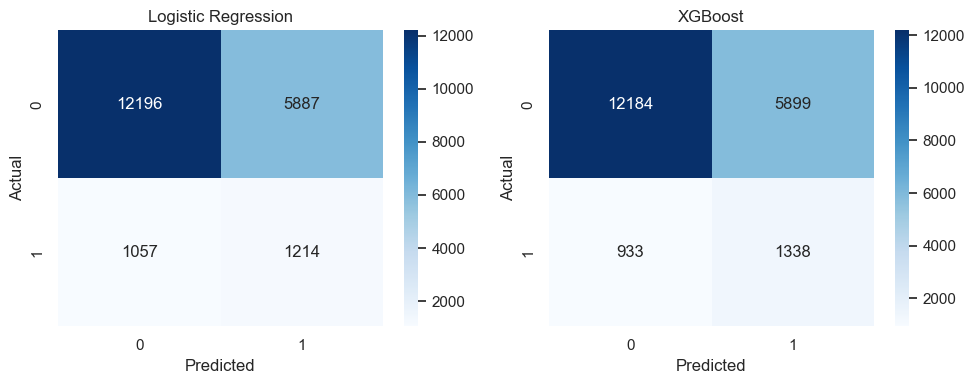

In [6]:
# Confusion matrices — matplotlib
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, [("Logistic Regression", lr), ("XGBoost", xgb)]):
    cm = confusion_matrix(y_test, model.predict(Xte))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

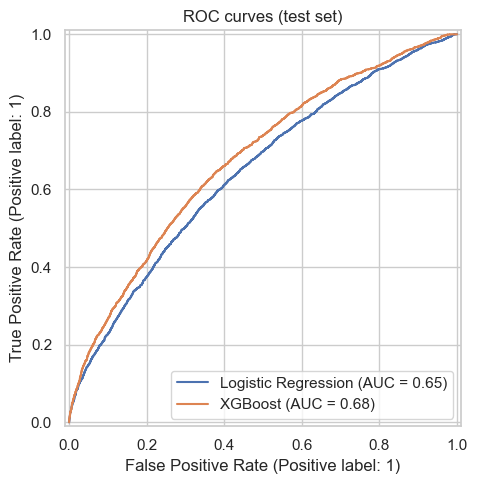

In [7]:
# ROC curves — matplotlib
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(lr, Xte, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(xgb, Xte, y_test, ax=ax, name="XGBoost")
ax.set_title("ROC curves (test set)")
plt.tight_layout(); plt.show()

**Reading the table:** XGBoost wins on recall/F1/ROC-AUC — it finds more of the true readmissions. Accuracy looks similar for both because the majority class dominates (that is exactly why accuracy misleads here). Neither model is great in absolute terms — readmission is hard to predict from admin data alone, and that is an honest, explainable result.

## 4. Feature importance (XGBoost)

These features were **important to the model's predictions** — not causes of readmission.

In [8]:
names = pre.get_feature_names_out()
imp = pd.DataFrame({"feature": names, "importance": xgb.feature_importances_})
top = imp.sort_values("importance", ascending=False).head(15).sort_values("importance")
print(top.sort_values("importance", ascending=False).to_string(index=False))

fig = px.bar(top, x="importance", y="feature", orientation="h",
             title="Top 15 XGBoost features (gain-based importance)")
fig.update_layout(yaxis_title="", xaxis_title="Importance")
fig.show()

                            feature  importance
  cat__prior_inpatient_visit_band_0    0.117197
 cat__prior_inpatient_visit_band_2+    0.114241
              num__number_inpatient    0.033144
      num__discharge_disposition_id    0.026126
cat__diagnosis_count_band_High (7+)    0.016325
  cat__prior_inpatient_visit_band_1    0.016106
 cat__length_of_stay_band_Long (5+)    0.013429
                cat__diabetesMed_No    0.011845
               cat__diabetesMed_Yes    0.010766
         num__high_utilization_flag    0.010651
                  cat__metformin_No    0.010587
              cat__metformin_Steady    0.010539
              num__number_diagnoses    0.010411
                  cat__metformin_Up    0.010225
              cat__glyburide_Steady    0.010081


**Interpretation:** prior-visit counts, number of diagnoses/medications and stay length drive the predictions — the same variables that stood out in SQL/EDA. Consistent story across all four analyses.

## Key Business Insights

1. Overall 30-day return rate is ~11% — the baseline KPI.
2. Past hospital use predicts future returns: 2+ prior inpatient stays → ~21% rate.
3. A small high-utilization slice (~16% of encounters) returns at ~19% — review this cohort first.
4. Ages 70–90 combine high rates with the largest volume (~67% of all readmissions come from 60–90).
5. Emergency admissions return more than elective (~11.5% vs ~10.4%).
6. Facility/transfer discharges show ~15–16% vs ~9% for routine home discharge.
7. Model agrees: prior visits, diagnosis/medication load and stay length matter most to predictions.

### Potential Business Actions

- Investigate the high-utilization cohort further (case review, follow-up calls).
- Review operational differences between emergency and elective pathways.
- Examine discharge planning for facility/transfer routes with higher historical returns.
- Use the model score as an analytical triage signal for further review — not a clinical decision.

### Limitations

- Observational data: associations only, no causal claims; no medical advice.
- ICD diagnosis codes were excluded from modeling (too granular for this scope).
- A1C testing was rare, limiting diabetes-specific signals.
- Model recall is modest — admin data alone cannot fully predict readmission.